# Analisi Dataset VisDrone (pre‑training)


In questa sezione introduco gli obiettivi dell'analisi e cosa viene misurato prima del training.


In [20]:
import json
from collections import Counter
from pathlib import Path
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

**Definizione dei path per i dataset**

In [21]:
sns.set_theme(style='whitegrid')
%matplotlib inline

CONFIG_PATH = Path('..') / 'config' / 'config.json'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    config = json.load(f)

train_cfg = config['data']['train']
val_cfg = config['data']['val']
class_map = {int(k): int(v) for k, v in config['data'].get('class_map', {}).items()}
valid_categories = set(config['data'].get('valid_categories', [])) or None

train_images_dir = Path('..') / train_cfg['images_dir']
train_ann_dir = Path('..') / train_cfg['annotations_dir']
val_images_dir = Path('..') / val_cfg['images_dir']
val_ann_dir = Path('..') / val_cfg['annotations_dir']


**Dimensione dataset (prima del parsing dettagliato)**

In [22]:
def count_images(dirpath):
    exts = {'.jpg', '.jpeg', '.png'}
    return sum(1 for p in dirpath.iterdir() if p.suffix.lower() in exts)

print('Train images:', count_images(train_images_dir))
print('Val images:', count_images(val_images_dir))


Train images: 6471
Val images: 548


Conteggio rapido box totali (train/val) prima dell'analisi dettagliata

In [23]:
def count_boxes(ann_dir):
    total = 0
    for ann_path in ann_dir.glob('*.txt'):
        with ann_path.open('r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) < 8:
                    continue
                try:
                    category = int(parts[5])
                except Exception:
                    continue
                if category <= 0:
                    continue
                if valid_categories and category not in valid_categories:
                    continue
                try:
                    w = float(parts[2])
                    h = float(parts[3])
                except Exception:
                    continue
                if w <= 1 or h <= 1:
                    continue
                total += 1
    return total

print('Train total boxes:', count_boxes(train_ann_dir))
print('Val total boxes:', count_boxes(val_ann_dir))


Train total boxes: 343197
Val total boxes: 38759


## 1) Parsing annotazioni e dataset


Descrivo come vengono lette e filtrate le annotazioni e come itero su immagini + label.


In [24]:
def parse_annotation(ann_path):
    boxes = []
    labels = []
    truncs = []
    occs = []
    if not ann_path.exists():
        return boxes, labels, truncs, occs
    with ann_path.open('r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 8:
                continue
            x, y, w, h, score, category, truncation, occlusion = parts[:8]
            category = int(category)
            if category <= 0:
                continue
            if valid_categories and category not in valid_categories:
                continue
            x = float(x)
            y = float(y)
            w = float(w)
            h = float(h)
            if w <= 1 or h <= 1:
                continue
            boxes.append((x, y, x + w, y + h))
            labels.append(class_map.get(category, category))
            truncs.append(int(truncation))
            occs.append(int(occlusion))
    return boxes, labels, truncs, occs


def iter_dataset(images_dir, ann_dir):
    for img_path in images_dir.glob('*'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        ann_path = ann_dir / (img_path.stem + '.txt')
        yield img_path, ann_path


## 2) Statistiche globali per split (train/val)


Riassumo quantità principali: immagini, box totali, immagini senza box e distribuzioni base.


In [25]:
def analyze_split(images_dir, ann_dir):
    class_counts = Counter()
    image_sizes = []
    box_wh = []
    box_areas = []
    box_area_rel = []
    aspect_ratios = []
    images_with_boxes = 0
    total_boxes = 0
    per_image_box_counts = []
    trunc_counts = Counter()
    occ_counts = Counter()

    for img_path, ann_path in iter_dataset(images_dir, ann_dir):
        try:
            with Image.open(img_path) as im:
                w, h = im.size
                image_sizes.append((w, h))
        except Exception:
            continue

        boxes, labels, truncs, occs = parse_annotation(ann_path)
        per_image_box_counts.append(len(boxes))
        if boxes:
            images_with_boxes += 1
        for (x1, y1, x2, y2), label, tr, oc in zip(boxes, labels, truncs, occs):
            bw = max(x2 - x1, 0.0)
            bh = max(y2 - y1, 0.0)
            area = bw * bh
            box_wh.append((bw, bh))
            box_areas.append(area)
            if w > 0 and h > 0:
                box_area_rel.append(area / (w * h))
            if bh > 0:
                aspect_ratios.append(bw / bh)
            class_counts[label] += 1
            trunc_counts[tr] += 1
            occ_counts[oc] += 1
            total_boxes += 1

    return {
        'class_counts': class_counts,
        'image_sizes': image_sizes,
        'box_wh': box_wh,
        'box_areas': box_areas,
        'box_area_rel': box_area_rel,
        'aspect_ratios': aspect_ratios,
        'images_with_boxes': images_with_boxes,
        'total_images': len(list(images_dir.glob('*'))),
        'total_boxes': total_boxes,
        'per_image_box_counts': per_image_box_counts,
        'trunc_counts': trunc_counts,
        'occ_counts': occ_counts,
    }

train_stats = analyze_split(train_images_dir, train_ann_dir)
val_stats = analyze_split(val_images_dir, val_ann_dir)

print('Train images with boxes:', train_stats['images_with_boxes'])
print('Val images with boxes:', val_stats['images_with_boxes'])
print('Train total boxes:', train_stats['total_boxes'])
print('Val total boxes:', val_stats['total_boxes'])


Train images with boxes: 6471
Val images with boxes: 548
Train total boxes: 343197
Val total boxes: 38759


## 3) Distribuzione classi (train vs val)


Confronto la distribuzione delle classi tra train e validation per evidenziare eventuali sbilanciamenti.


In [26]:
def class_distribution_df(stats, split_name):
    counts = stats['class_counts']
    total = sum(counts.values())
    rows = []
    for cls_id, count in sorted(counts.items()):
        pct = (count / total * 100.0) if total else 0.0
        rows.append({'class_id': cls_id, 'count': count, 'percent': pct, 'split': split_name})
    return pd.DataFrame(rows)

train_df = class_distribution_df(train_stats, 'train')
val_df = class_distribution_df(val_stats, 'val')
class_df = pd.concat([train_df, val_df], ignore_index=True)

class_df


,class_id,count,percent,split
0,1,79337,23.117044,train
1,2,27056,7.883519,train
2,3,10479,3.053348,train
3,4,144864,42.210159,train
4,5,24956,7.271625,train
5,6,12875,3.751490,train
6,7,4812,1.402110,train
7,8,3246,0.945812,train
8,9,5926,1.726705,train
9,10,29646,8.638187,train


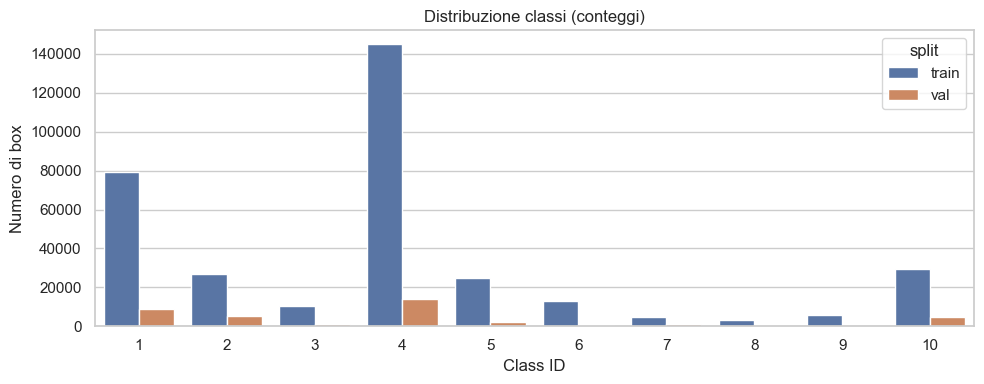

In [27]:
plt.figure(figsize=(10, 4))
sns.barplot(data=class_df, x='class_id', y='count', hue='split')
plt.title('Distribuzione classi (conteggi)')
plt.xlabel('Class ID')
plt.ylabel('Numero di box')
plt.tight_layout()
plt.show()


## 4) Dimensioni immagini e box


Analizzo risoluzione immagini e dimensioni delle bounding box per capire la scala degli oggetti.


In [28]:
def stats_to_dfs(stats):
    image_sizes = np.array(stats['image_sizes'], dtype=np.float32)
    box_wh = np.array(stats['box_wh'], dtype=np.float32)

    image_df = pd.DataFrame({
        'img_w': image_sizes[:, 0] if image_sizes.size else [],
        'img_h': image_sizes[:, 1] if image_sizes.size else [],
    })

    box_df = pd.DataFrame({
        'box_w': box_wh[:, 0] if box_wh.size else [],
        'box_h': box_wh[:, 1] if box_wh.size else [],
    })
    if stats['box_areas']:
        box_df['box_area'] = stats['box_areas']
    if stats['box_area_rel']:
        box_df['box_area_rel'] = stats['box_area_rel']
    if stats['aspect_ratios']:
        box_df['box_aspect'] = stats['aspect_ratios']

    return image_df, box_df

train_image_df, train_box_df = stats_to_dfs(train_stats)
train_image_df.head()


,img_w,img_h
0,960.0,540.0
1,960.0,540.0
2,960.0,540.0
3,1360.0,765.0
4,1360.0,765.0


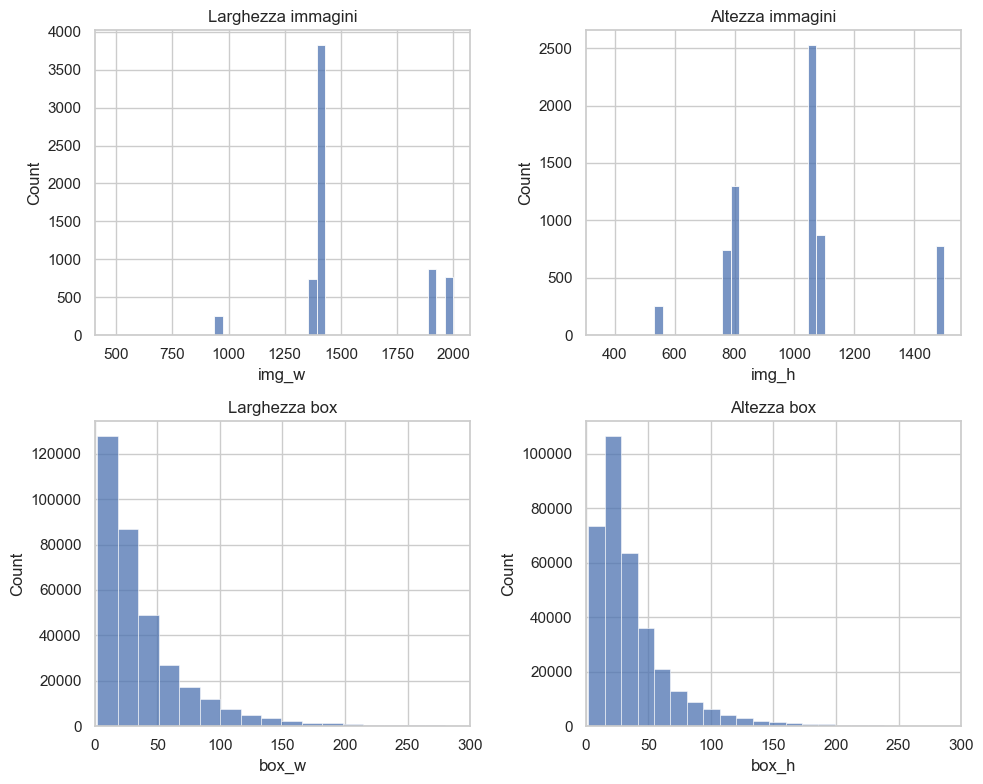

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.histplot(train_image_df['img_w'], bins=40, ax=axes[0, 0])
axes[0, 0].set_title('Larghezza immagini')
sns.histplot(train_image_df['img_h'], bins=40, ax=axes[0, 1])
axes[0, 1].set_title('Altezza immagini')
sns.histplot(train_box_df['box_w'], bins=60, ax=axes[1, 0])
axes[1, 0].set_title('Larghezza box')
axes[1, 0].set_xlim(0, 300)
sns.histplot(train_box_df['box_h'], bins=60, ax=axes[1, 1])
axes[1, 1].set_title('Altezza box')
axes[1, 1].set_xlim(0, 300)
plt.tight_layout()
plt.show()


## 5) Numero di box per immagine


Misuro quante annotazioni per immagine ci sono e la percentuale di immagini vuote.


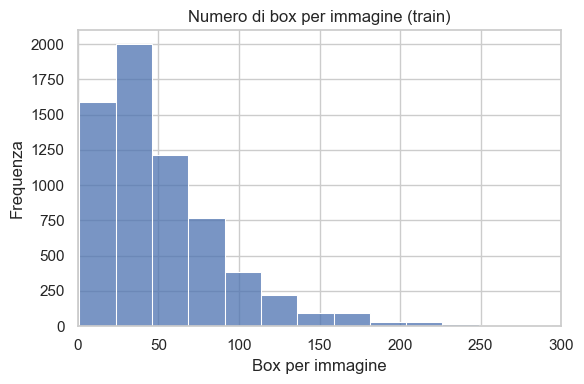

Percentuale immagini senza box (train): 0.00%


In [30]:
plt.figure(figsize=(6,4))
sns.histplot(train_stats['per_image_box_counts'], bins=40)
plt.title('Numero di box per immagine (train)')
plt.xlabel('Box per immagine')
plt.ylabel('Frequenza')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

empty_ratio = 100 * sum(1 for x in train_stats['per_image_box_counts'] if x == 0) / max(len(train_stats['per_image_box_counts']), 1)
print(f"Percentuale immagini senza box (train): {empty_ratio:.2f}%")


## 6) Truncation e Occlusion (qualità annotazioni)


Esamino il livello di troncamento e occlusione per stimare la qualità/difficoltà delle annotazioni.


In [31]:
print('Truncation counts (train):', dict(train_stats['trunc_counts']))
print('Occlusion counts (train):', dict(train_stats['occ_counts']))


Truncation counts (train): {0: 329824, 1: 13373}
Occlusion counts (train): {1: 142248, 0: 167298, 2: 33651}
